In [18]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.data import Data
from ClassGraphDat import GraphDataset
# from graphDat import GraphDataset
# from ClassGraphDat import GraphDataset

torch.manual_seed(42)

In [19]:

class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        # self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow="source_to_target", root_weight=False)
        # self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow="source_to_target", root_weight=False)
        # self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow="source_to_target", root_weight=False)
        self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow="target_to_source", root_weight=False)
        self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow="target_to_source", root_weight=False)
        self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow="target_to_source", root_weight=False)
        self.lin1 = nn.Linear(hidden_channels, int(hidden_channels/2))
        self.lin2 = nn.Linear(int(hidden_channels/2), out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        x = F.dropout(F.relu(self.lin1(x)), p=0.2)
        x = self.lin2(x)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x += identity  # Element-wise addition
        # x = self.sm(x)
        return x

In [20]:
# # Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
# def loss_function(reconstructed_x, original_x):
#     # print(/)
#     return F.cross_entropy(reconstructed_x, original_x)

def cosine_loss(adj, emb):
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    target_adjacency[adj[0], adj[1]] = 1
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)

In [21]:
def train(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    printlosses = []
    # lossfunc = nn.CrossEntropyLoss()
    # print(data_loader)
    for feat, edge in data_loader:
        optimizer.zero_grad()
        # pdb.set_trace()
        # print(np.shape(feat), np.shape(edges))
        # print('in main: ', np.shape(feat), np.shape(edges))
        features = feat.squeeze_(0).to(device)
        # globalInfo = glob.squeeze_(0).to(device)
        edges = edge.squeeze_(0).to(device)
        # embed = model(torch.cat([globalInfo, features], dim=1), edges)
        embed = model(features, edges)

        origs.append(features.detach())
        # print(np.shape(embed), np.shape(data[2][0]))
        # print()
        # print(data[2][0][0], embed[0].detach())
        # loss = lossfunc(embed, data[2][0].to(device))
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))
        # loss = loss_function(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        loss = cosine_loss(edges, embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        embeddings.append(embed.detach())
        printlosses.append(loss.detach().item())
        if len(printlosses)%100 == 0:
            printlosses = printlosses[-100:]
            print(np.sum(printlosses)/100.0)
        # print(total_loss)
    return total_loss / len(data_loader), embeddings, origs

In [22]:
# data = torch.load('finished_graph.pth')
# print(data)
    
fil2 = open('alltime.pickle', 'rb')
meta = pickle.load(fil2)
fil2.close()


In [23]:
# np.shape(data['feat'][1])

In [24]:
# folder_graph = '../CDC/allenvsmore/'
device = "cpu"
# fname = 'small_graphs.pth'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
hC = 15
inC = 40


# data = torch.load('finished_graph.pth')

# Create a graph data object
# graph = Data(x=node_features, edge_index=adjacency_matrix.coalesce().indices(), edge_attr=edge_features)

fg = './oneGraph_FinishedOnly/'
files = os.listdir(fg)
files = [file for file in files if file.endswith('.pickle')]
dataset = GraphDataset(fg, files, meta)
# dataset = GraphDataset('all_time_classes_quals.pickle')
# print('data loaded')
# print(dataset)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
actuals = []
final_loss = []
embeddings = []
outchannels = 3

# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


In [25]:
# print(len(dataset))
# for feat, edges, _, _  in dataloader:
#     print(np.shape(feat), np.shape(edges))
    # break

In [26]:
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.1)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
# losses = []
embeds = []
# torch.autograd.set_detect_anomaly(True)
acts = []
for epoch in range(1, 7):  # Number of epochs
    # loss, embed, orig = train(model, dataloader, optimizer, device)
    loss, _, _ = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)
# model.eval()
# # Assuming encoder and decoder are your model's components
# encoder_state_dict = model.state_dict()
# # decoder_state_dict = model.decoder.state_dict()
# # Save the state dictionaries
# torch.save(encoder_state_dict, './Finembed_1graph'+str(outchannels)+'.pth')

0.8456497359275817
0.7928494393825531
0.7732477003335952
0.7696546590328217
0.7771599501371383
0.7692220836877823
0.7684804326295853
0.7648586124181748
Epoch 1, Loss: 0.7817
0.7657021516561509
0.7724252384901047
0.7645058453083038
0.7630535036325454
0.7646999418735504
0.7641217589378357
0.7639534956216812
0.7696481746435165
Epoch 2, Loss: 0.7661
0.7607208693027496
0.7641668802499771
0.7644372797012329
0.7631878334283829
0.766093693971634
0.7628928411006928
0.7632169580459595
0.7603587436676026
Epoch 3, Loss: 0.7632
0.7694783860445022
0.7622934007644653
0.7606366276741028
0.7625114011764527
0.7646827745437622
0.7675960046052933
0.7675965934991836
0.7635859334468842
Epoch 4, Loss: 0.7650
0.7636024576425552
0.7633245730400086
0.7624495476484299
0.7604057365655899
0.7627988857030868
0.7589998173713685
0.7627518612146378
0.7619561076164245
Epoch 5, Loss: 0.7622
0.7616819334030152
0.7664513248205185
0.7587830275297165
0.7614691478013992
0.770089156627655
0.7628940826654435
0.7622087121009826

In [27]:
optimizer = optim.Adam(model.parameters(), lr=0.01)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
for epoch in range(1, 10):  # Number of epochs
    # loss, embed, orig = train(model, dataloader, optimizer, device)
    loss, _, _ = train(model, dataloader, optimizer, device)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# model.eval()
# encoder_state_dict = model.state_dict()
# # decoder_state_dict = model.decoder.state_dict()
# # Save the state dictionaries
# torch.save(encoder_state_dict, './embed_1graph'+str(outchannels)+'.pth')

0.7539489793777466
0.7566450732946396
0.7550943350791931
0.748689420223236
0.7458616614341735
0.7446633154153823
0.7420523816347122
0.7430192995071411
Epoch 1, Loss: 0.7480
0.7413842707872391
0.739431346654892
0.7424461030960083
0.7406201779842376
0.7433241283893586
0.7398098903894424
0.7401773059368133
0.741115391254425
Epoch 2, Loss: 0.7411
0.7370343470573425
0.7381436866521836
0.7436295962333679
0.7423094767332077
0.7458619272708893
0.740550189614296
0.7410655099153519
0.7401461899280548
Epoch 3, Loss: 0.7409
0.7387033355236053
0.741976665854454
0.7414698451757431
0.7375640863180161
0.7416342616081237
0.7395129364728927
0.7365975701808929
0.7392664211988449
Epoch 4, Loss: 0.7395
0.7398728233575821
0.7388046151399612
0.7375359845161438
0.7384367138147354
0.7380238085985183
0.7385162168741226
0.738610805273056
0.738731501698494
Epoch 5, Loss: 0.7386
0.7382116806507111
0.7378458482027054
0.7373287546634674
0.7365935158729553
0.7380596941709519
0.7375937592983246
0.737608237862587
0.737

In [28]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
for epoch in range(1, 5):  # Number of epochs
    # loss, embed, orig = train(model, dataloader, optimizer, device)
    loss, embed, orig = train(model, dataloader, optimizer, device)
    embeds.append(embed)
    acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
model.eval()
encoder_state_dict = model.state_dict()
# decoder_state_dict = model.decoder.state_dict()
# Save the state dictionaries
torch.save(encoder_state_dict, str(hC) + 'Finembed_1graph'+str(outchannels)+'.pth')
fl = open(str(hC) + 'embeddings_3_5.pickle', 'wb')
pickle.dump(embeds, fl)
fl.close()

fl = open(str(hC) + 'actuals_3_5.pickle', 'wb')
pickle.dump(acts, fl)
fl.close()


0.7374655711650848
0.7357862389087677
0.7361566460132599
0.7368652212619782
0.7363025265932083
0.7351946514844895
0.7357455402612686
0.7357852327823639
Epoch 1, Loss: 0.7361
0.7365394866466523
0.7352368235588074
0.736652449965477
0.7385027092695237
0.7354873669147491
0.7378657311201096
0.7359742563962937
0.7361564081907273
Epoch 2, Loss: 0.7364
0.7352794897556305
0.7354117208719253
0.7346833801269531
0.7358481979370117
0.7352352333068848
0.737694303393364
0.7354838901758194
0.7358537536859512
Epoch 3, Loss: 0.7358
0.7344637316465378
0.7372629505395889
0.7370820343494415
0.7368067979812623
0.7348994612693787
0.7346819943189621
0.7373217070102691
0.7357692706584931
Epoch 4, Loss: 0.7360


In [29]:
# for i in embeddings:
#     df = pd.DataFrame(emb, columns=['x', 'y', 'z'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_emb.csv')

#     df = pd.DataFrame(arrpos, columns=['pose1', 'pose2', 'pose3', 'pose4'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_poses.csv')

#     df = pd.DataFrame(arrqual, columns=['qual1', 'qual2', 'qual3', 'qual4'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_quals.csv')


#     df = pd.DataFrame(arr_global_info, columns=['1', '2', '3', '4'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_global_info.csv')

#     df = pd.DataFrame(arrcol, columns=['colors'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_colors.csv')

#     df = pd.DataFrame(arr_num_agents, columns=['num_agents'])
#     df.to_csv('./RS/LinNew_ALLENVS_AGENTS_num_agents.csv')
# optimizer = optim.Adam(model.parameters(), lr=0.0001)
# # scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
# for epoch in range(1, 5):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)
#     # scheduler.step(loss)
# encoder_state_dict = model.state_dict()
# # decoder_state_dict = model.decoder.state_dict()
# # Save the state dictionaries
# torch.save(encoder_state_dict, './LinNew_encoder_state_dict'+str(outchannels)+'.pth')

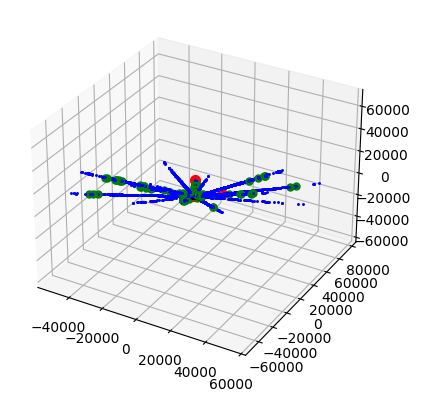

In [37]:
COMMIT_THRESHOLD = 0.5

def node_to_color_black(node):
    if node[3] == 0.0:
        return True
    else:
        return False

def node_to_color_green(node, quals):
    # pdb.set_trace()
    nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] == np.max(quals):
            return True
        else:
            return False
    else:
        return False
    
def node_to_color_red(node, quals):
    # pdb.set_trace()
    nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] != np.max(quals):
            return True
        else:
            return False
    else:
        return False
# import matplotlib.pyplot as plt
# embeds
q = [0.035, 0.637, 0.402, 0.347]
# colors = ['r', 'g', 'b']
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
# np.shape(embeds[-1][0])
# e = embeds[-1][0]
arr = []
counter = 0
for ee, oo in zip(embeds[-1], acts[-1]):
    counter += 1
    for id, (e, o) in enumerate(zip(ee, oo)):
        if node_to_color_black(o):
            color = 'k'
            # print(id, o[0:4])
            sz = 50
        elif node_to_color_red(o, q):
            color = 'r'
            sz = 200
        elif node_to_color_green(o,q):
            color = 'g'
            sz = 100
        else:
            color = 'b'
            sz = 5
        # print(e)
        # break
        arr.append([e[0], e[1], e[2], color, sz])
        ax.scatter(e[0], e[1], e[2], marker='.', c=color, s=sz)
    if counter == 100:
        break
plt.show()

# np.save('arr.npy', arr)

# sf = nn.Softmax(dim=1)
# x = torch.tensor([[-0.5207, -0.6732,  0.1790, -0.5166], [-0.3699, -0.7055, -0.0155, -0.2880]])
# print(np.shape(x))
# print(sf(x))

In [31]:
# import torch
# import torch.nn.functional as F
# # Example of target with class indices
# input = torch.randn(3, 5, requires_grad=True)
# print(input)
# target = torch.randint(5, (3,), dtype=torch.int64)
# print(target)
# loss = F.cross_entropy(input, target)
# print(loss)
# loss.backward()
# print(loss)

# # Example of target with class probabilities
# input = torch.randn(3, 5, requires_grad=True)
# target = torch.randn(3, 5).softmax(dim=1)
# print(input)
# print(target)
# loss = F.cross_entropy(input, target)
# print(loss)
# loss.backward()
# print(loss)

# q0 >= q1 >= q2 >= q3
# [q0 site recruiters, q1 site recruiters, q2 site recruiters, q3 site recruiters, agent state, site x, site y, site quality ...]

In [ ]:
import numpy as np
import scipy.io

# x = np.linspace(0, 2 * np.pi, 100)
# y = np.cos(x)
arrdict = {'x':[], 'y':[], 'z':[], 'col':[], 'sz':[]}
for i in arr:
    arrdict['x'].append(i[0])
    arrdict['y'].append(i[1])
    arrdict['z'].append(i[2])
    arrdict['col'].append(i[3])
    arrdict['sz'].append(i[4])


scipy.io.savemat('test_time.mat', arrdict)


In [32]:

# # fil2 = open('MULTIPLEedgeList.pickle', 'rb')
# # meta1 = pickle.load(fil2)
# # fil2.close()

# # fil2 = open('MULTIPLEnodeIDs.pickle', 'rb')
# # meta2 = pickle.load(fil2)
# # fil2.close()
# import torch
# from torch import nn
# import torch_geometric
# from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
# import torch
# import networkx as nx 
# from torch.utils.data import Dataset, DataLoader
# import pickle
# import pdb 
# import numpy as np
# from torch_geometric.data import Data
# import networkx as nx
# import numpy as np
# import pandas as pd 
# import pickle
# import pdb
# from torch_geometric.loader import DataLoader
# import torch.optim as optim
# import torch.nn.functional as F
# from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
# import matplotlib.pyplot as plt
# import sys
# import os
# sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
# from sklearn.neighbors import kneighbors_graph
# from torch.optim.lr_scheduler import ReduceLROnPlateau
# from torch_geometric.data import Data
# from ClassGraphDat import GraphDataset
# # from graphDat import GraphDataset
# # from ClassGraphDat import GraphDataset

# torch.manual_seed(42)

# fil2 = open('alltime.pickle', 'rb')
# meta = pickle.load(fil2)
# fil2.close()

# fg = './oneGraph/'
# files = os.listdir(fg)
# files = [file for file in files if file.endswith('.pickle')]
# dataset = GraphDataset(fg, files, meta)
# # print(files)


In [33]:
# dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=1)


In [34]:
# for n, e in dataloader:
#     print(np.shape(n), np.shape(e))